<a href="https://colab.research.google.com/github/kauefs/DS/blob/%40/notebooks/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font color=#F0F0F0 size=8px font-family=Georgia>
<strong><ins>ƊⱭȾɅViƧi&#x1F9FF;Ƞ</ins>&trade;</strong></font>

![2025.02.11  ](https://img.shields.io/badge/2025.02.11-000000)

[![License    ](https://img.shields.io/badge/Apache--2.0-D22128?style=flat&logo=apache&logoColor=CB2138&label=License&labelColor=6D6E71)](https://www.apache.org/licenses/LICENSE-2.0)

[![GitHub     ](https://img.shields.io/badge/-000000?logo=github&logoColor=FFFFFF)](https://github.com/kauefs/)
[![Medium     ](https://img.shields.io/badge/-000000?logo=medium&logoColor=FFFFFF)](https://medium.com/@kauefs)
[![LinkedIn   ](https://img.shields.io/badge/in-0077B5?logo=linkedin&logoColor=FFFFFF)](https://www.linkedin.com/in/kauefs/)
[![Python     ](https://img.shields.io/badge/3-646464?logo=python&logoColor=FFDE57&labelColor=4584B6)](https://www.python.org/)

[![ƊⱭȾɅViƧi🧿Ƞ](https://img.shields.io/badge/ƊⱭȾɅViƧi&#x1F9FF;Ƞ&trade;-0065FF?style=plastic&label=&copy;2025&labelColor=0065FF)](https://datavision.one/)

Based on NoteBook by [BrunoSouza](https://github.com/BruninSouza/Analise-TWD/)

In [1]:
!date

Tue Feb 11 12:41:41 AM UTC 2025


In [1]:
!date

Wed Feb 12 01:53:00 AM UTC 2025


In [2]:
# @title Settings
# Libraries:
import      numpy                   as   np
import     pandas                   as   pd
import  missingno                   as   msno
import    seaborn                   as   sns
import                                   sys
import matplotlib.pyplot            as   plt
import matplotlib.ticker            as   ticker
from   statistics                 import mode
# Configurations:
print('System Ready: Python –'  ,        sys.version)
%matplotlib inline
%config     InlineBackend.figure_format='svg'
%precision     2
session_id   = 2
np.random.seed(2)
random_state = 2
pd.options.plotting.matplotlib.register_converters = True
pd.options.display.max_columns         =             None
plt.rcParams[  'figure.autolayout']    =             True
plt.rcParams[    'font.family']        =                                        'sans-serif'
sns.set_theme(context='notebook', style='whitegrid', palette='colorblind', font='sans-serif', font_scale=1.15, color_codes=True, rc={'grid.color':'1','grid.linestyle':':'})
FontT={'family':'sans-serif'    ,'color':'#000000' ,  'size':13,     'fontweight':'semibold'}
FontY={'family':'sans-serif'    ,'color':'#FF4500' ,  'size':10,     'fontweight': 'regular'}
FontX={'family':'sans-serif'    ,'color':'#4CAF50' ,  'size':10,     'fontweight': 'regular'}

System Ready: Python – 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]


In [3]:
# Get IMDB DataSet
ratings =pd.read_csv('https://datasets.imdbws.com/title.ratings.tsv.gz', delimiter='\t', engine='python', low_memory= True)
basics  =pd.read_csv('https://datasets.imdbws.com/title.basics.tsv.gz' , delimiter='\t',                  low_memory= True, na_values=['\\N'], dtype={'startYear'   :'Int64'})
episodes=pd.read_csv('https://datasets.imdbws.com/title.episode.tsv.gz', delimiter='\t', engine='python', low_memory= True, na_values=['\\N'], dtype={'seasonNumber':'Int64','episodeNumber':'Int64'})
ratingsPop=ratings[ratings.numVotes>200000]
seriesPop =(basics.query ('titleType == "tvSeries" and startYear >= 2000')
                  .merge (ratingsPop, on='tconst')
                  .filter(['tconst' ,'primaryTitle']))
seriesPop
episodesPop=(seriesPop.merge (episodes, left_on='tconst', right_on='parentTconst', suffixes=['Series',''])
                      .merge (basics[['tconst','primaryTitle','startYear','genres','runtimeMinutes']], on='tconst')
                      .merge (ratings, on='tconst')
                      .rename(columns={'tconstSeries'  :'serieID'  ,
                                       'primaryTitle_x':'serie'    ,
                                       'seasonNumber'  :'season'   ,
                                       'tconst'        :'episodeID',
                                       'episodeNumber' :'number'   ,
                                       'primaryTitle_y':'episode'  ,
                                       'averageRating' :'rating'   ,
                                       'numVotes'      :'votes'    ,
                                       'startYear'     :'year'     ,
                                       'genres'        :'genre'    ,
                                       'runtimeMinutes':'runtime'})
                      .filter(['serie','season','number','episode' ,
                               'year' ,'genre' ,'runtime','votes','rating'])
                      .sort_values(by=['serie' ,'season','number']))
episodesPop.to_csv('IMDB.csv', index=False)
print('DataBase Compiled & Saved!')

<ipython-input-3-8fa05ea05947>:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  basics  =pd.read_csv('https://datasets.imdbws.com/title.basics.tsv.gz' , delimiter='\t',                  low_memory= True, na_values=['\\N'], dtype={'startYear'   :'Int64'})
<ipython-input-3-8fa05ea05947>:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  seriesPop =(basics.query ('titleType == "tvSeries" and startYear >= 2000')


DataBase Compiled & Saved!


In [4]:
# @title DataSet
DF=pd.read_csv('https://github.com/kauefs/DS/raw/refs/heads/@/datasets/IMDB.csv').query('serie=="Doctor Who"').reset_index(drop=True)
DF.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   serie    175 non-null    object 
 1   season   164 non-null    float64
 2   number   164 non-null    float64
 3   episode  175 non-null    object 
 4   year     175 non-null    int64  
 5   genre    175 non-null    object 
 6   runtime  175 non-null    float64
 7   votes    175 non-null    int64  
 8   rating   175 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 12.4+ KB


In [5]:
# @title Missing Values
print('Total Missing Data: {:,.0f}'.format(DF.isnull().sum().values.sum()))
print(DF.isnull().sum()            /       DF.shape[ 0                   ])
# DF.isnull().sum()#.max()

Total Missing Data: 22
serie      0.000000
season     0.062857
number     0.062857
episode    0.000000
year       0.000000
genre      0.000000
runtime    0.000000
votes      0.000000
rating     0.000000
dtype: float64


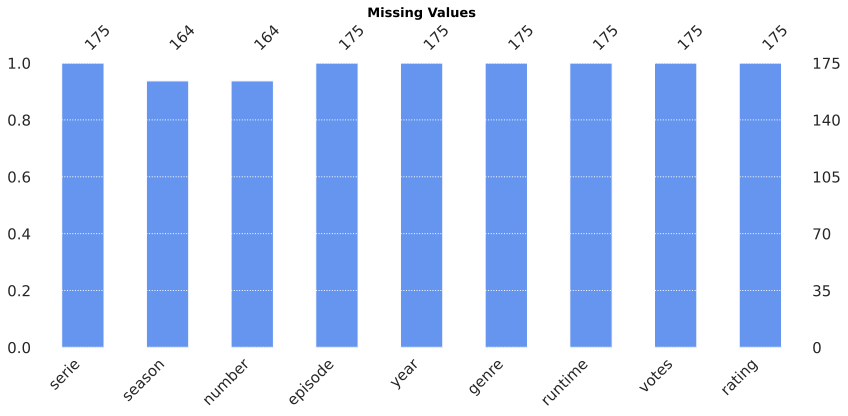

In [6]:
# Visualizing Missing Values:
# https://coderzcolumn.com/tutorials/data-science/missingno-visualize-missing-data-in-python
msno.bar(DF, figsize=(12, 6), fontsize=15, labels=None, label_rotation=45, log=False, color='#6595EE',
         filter=None, n=0, p=0, sort=None, ax=None, orientation=None)
plt.title('Missing Values'    , fontdict =   FontT,     loc='center')
plt.show( )

In [7]:
# @title Duplicated Values
print('Total Duplicated Values: {:,.0f}'.format(DF.duplicated().sum()))

Total Duplicated Values: 0


In [8]:
# @title Unique Values
print('Unique Values:\n{}\n'.format(DF.nunique()))

Unique Values:
serie        1
season      13
number      15
episode    175
year        18
genre        1
runtime     28
votes      174
rating      43
dtype: int64



In [9]:
# Fill Missing Values:
# DF.fillna(0)
# Features:
print    ('Features:\n{}' .format(DF.columns.values))

Features:
['serie' 'season' 'number' 'episode' 'year' 'genre' 'runtime' 'votes'
 'rating']


In [10]:
# @title Statistics Summary
DF.describe()#.T

,season,number,year,runtime,votes,rating
count,164.000000,164.00000,175.000000,175.000000,175.000000,175.000000
mean,6.536585,6.27439,2012.131429,49.320000,7759.617143,7.624571
std,3.526221,3.87904,4.970012,7.712536,2495.055954,1.083270
min,1.000000,0.00000,2005.000000,41.000000,3507.000000,4.200000
25%,3.750000,3.00000,2008.000000,45.000000,6389.500000,7.000000
50%,6.500000,6.00000,2011.000000,46.000000,7582.000000,7.600000
75%,9.000000,9.25000,2016.500000,50.000000,8708.000000,8.500000
max,13.000000,14.00000,2022.000000,88.000000,25086.000000,9.800000


In [11]:
# Data Visualization:
DF

,serie,season,number,episode,year,genre,runtime,votes,rating
0,Doctor Who,1.0,1.0,Rose,2005,"Adventure,Drama,Sci-Fi",45.0,11190,7.5
1,Doctor Who,1.0,2.0,The End of the World,2005,"Adventure,Drama,Sci-Fi",45.0,9856,7.5
2,Doctor Who,1.0,3.0,The Unquiet Dead,2005,"Adventure,Drama,Sci-Fi",45.0,9216,7.4
3,Doctor Who,1.0,4.0,Aliens of London,2005,"Adventure,Drama,Sci-Fi",45.0,8933,6.9
4,Doctor Who,1.0,5.0,World War Three,2005,"Adventure,Drama,Sci-Fi",45.0,8650,6.9
...,...,...,...,...,...,...,...,...,...
170,Doctor Who,NaN,NaN,The End of Time: Part One,2009,"Adventure,Drama,Sci-Fi",60.0,6933,8.2
171,Doctor Who,NaN,NaN,The End of Time: Part Two,2010,"Adventure,Drama,Sci-Fi",75.0,7763,8.9
172,Doctor Who,NaN,NaN,The Power of the Doctor,2022,"Adventure,Drama,Sci-Fi",88.0,4533,7.6
173,Doctor Who,NaN,NaN,The Day of the Doctor,2013,"Adventure,Drama,Sci-Fi",77.0,20429,9.3


In [12]:
# @title Episodes Popularity
mean  =np.mean  (DF['votes'])
median=np.median(DF['votes'])
moda  =mode     (DF['votes'])
var   =np.var   (DF['votes'])
std   =np.std   (DF['votes'])
results=('Centrality:\n'
        f' Mean:               {mean:,.2f}\n'
        f' Median:             {median:,.0f}\n'
        f' Mode:               {moda:,.0f}\n\n'
         'Dispersion:\n'
        f' Variance:       {var:,.2f}\n'
        f' Standard Deviation: {std:,.2f}')
print(results)

Centrality:
 Mean:               7,759.62
 Median:             7,582
 Mode:               9,125

Dispersion:
 Variance:       6,189,731.05
 Standard Deviation: 2,487.92


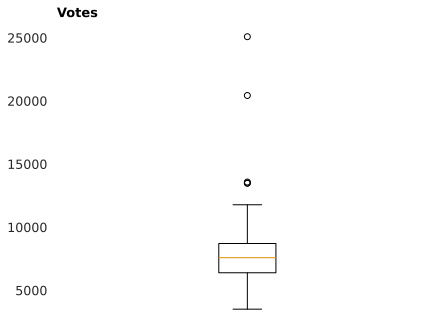

In [13]:
# Box Plot:
plt.figure(tight_layout=True)
plt.boxplot(DF['votes'],)
plt.title ('Votes', fontdict=FontT, loc='left')
plt.ylabel('')
plt.xlabel('')
plt.xticks([])
plt.box(False)
plt.show(    )

In [14]:
# Most Popular Episode:
DF.sort_values(by='votes', ascending=False).head(1)

,serie,season,number,episode,year,genre,runtime,votes,rating
37,Doctor Who,3.0,10.0,Blink,2007,"Adventure,Drama,Sci-Fi",45.0,25086,9.8


In [15]:
# Least Popular Episode:
DF.sort_values(by='votes', ascending=True).head(1)

,serie,season,number,episode,year,genre,runtime,votes,rating
168,Doctor Who,NaN,NaN,Legend of the Sea Devils,2022,"Adventure,Drama,Sci-Fi",48.0,3507,4.6


In [16]:
# Most Popular SeaSon:
seasons=DF.groupby('season')['votes'].mean()
seasons.sort_values(ascending=False)

,votes
season,
3.0,9724.642857
1.0,9522.615385
2.0,9189.428571
4.0,8976.857143
5.0,8519.461538
11.0,8364.818182
6.0,7631.500000
8.0,7392.000000
7.0,7272.866667


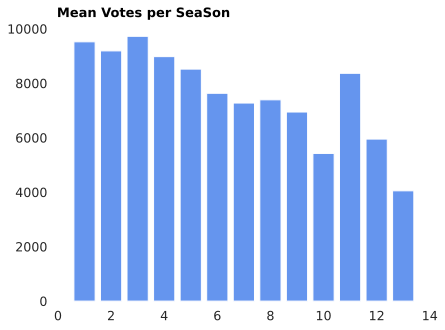

In [17]:
# Chart:
plt.figure(tight_layout=True)
plt.bar(seasons.index, seasons.values, color='#6595EE')
plt.title('Mean Votes per SeaSon', fontdict=FontT, loc='left')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.show(    )

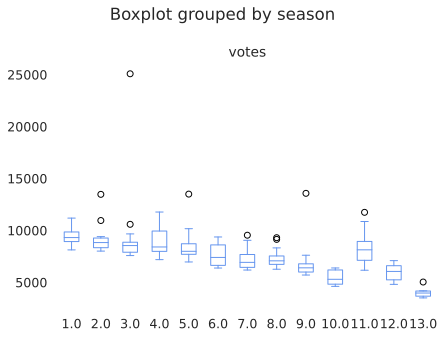

In [18]:
DF.boxplot(by='season', column='votes', color='#6595EE');
plt.xlabel('')
plt.box(False)

In [19]:
# Least Popular SeaSon:
seasons.sort_values().head(1)

,votes
season,
13.0,4049.666667


In [20]:
# @title Episodes Quality
# Mean Rating:
moda  =mode     (DF['rating'])
var   =np.var   (DF['rating'])
print(f'mode {moda:,.6f}\n',
      f'var {var:,.6f}')
DF['rating'].describe()

mode 7.500000
 var 1.166768


,rating
count,175.000000
mean,7.624571
std,1.083270
min,4.200000
25%,7.000000
50%,7.600000
75%,8.500000
max,9.800000


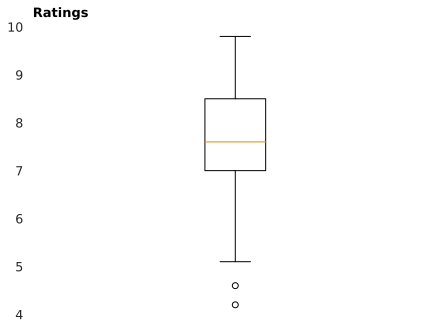

In [21]:
# Box Plot:
plt.figure(tight_layout=True)
plt.boxplot(DF['rating'])
plt.title (    'Ratings', fontdict=FontT, loc='left')
plt.ylabel('')
plt.xlabel('')
plt.xticks([])
plt.box(False)
plt.show(    )

In [22]:
# Best Episode:
DF.sort_values(by='rating', ascending=False).head(1)

,serie,season,number,episode,year,genre,runtime,votes,rating
37,Doctor Who,3.0,10.0,Blink,2007,"Adventure,Drama,Sci-Fi",45.0,25086,9.8


In [23]:
# Worst Episode:
DF.sort_values(by='rating', ascending=True).head(1)

,serie,season,number,episode,year,genre,runtime,votes,rating
150,Doctor Who,12.0,3.0,Orphan 55,2020,"Adventure,Drama,Sci-Fi",46.0,7093,4.2


In [24]:
# Best SeaSon:
seasons=DF.groupby('season')['rating'].mean()
seasons.sort_values(ascending=False)

,rating
season,
4.0,8.307143
5.0,8.061538
9.0,8.042857
3.0,8.014286
6.0,8.014286
1.0,7.907692
2.0,7.807143
8.0,7.684615
7.0,7.673333


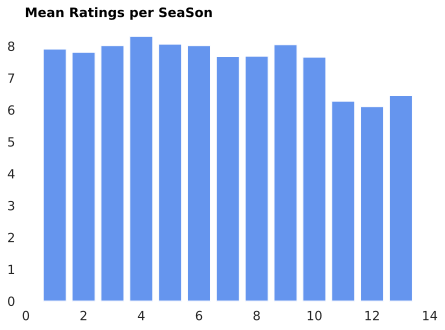

In [25]:
# Chart:
plt.figure(tight_layout=True)
plt.bar(seasons.index, seasons.values, color='#6595EE')
plt.title('Mean Ratings per SeaSon', fontdict=FontT, loc='left')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.show(    )

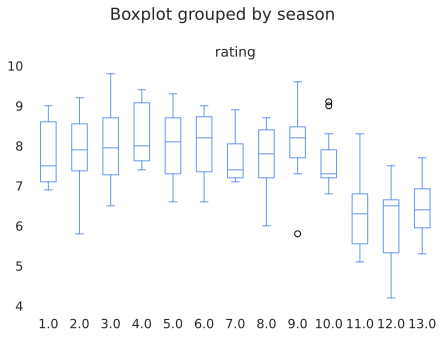

In [26]:
DF.boxplot(by='season', column='rating', color='#6595EE');
plt.xlabel('')
plt.box(False)

In [27]:
# Worst SeaSon:
seasons.sort_values(ascending=True).head(1)

,rating
season,
12.0,6.1


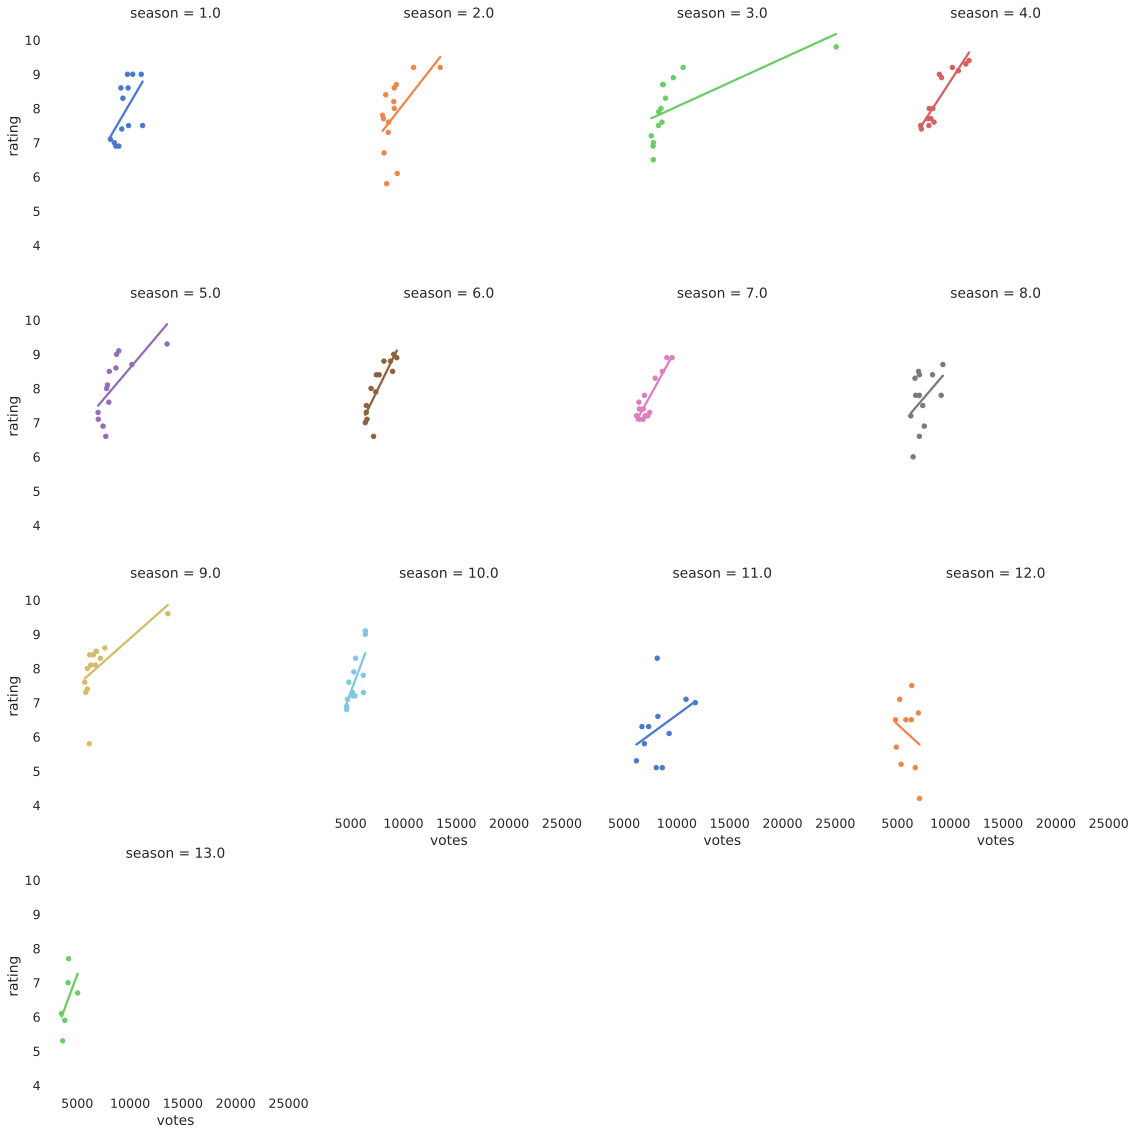

In [28]:
# @title Correlations
# Votes & Ratings:
sns.lmplot(data=DF,  x='votes', y='rating' , col='season' , hue='season', col_wrap=4, palette='muted',
             ci=None, height=4, scatter_kws={'s':20,'alpha':1})
sns.despine(top=True, left=True, bottom=True, right=True)
plt.show()

In [29]:
# PearSon – SpearMan – KenDall:
pd.Series({'pearson' :DF['votes'].corr(DF['rating'], method='pearson' ),
           'spearman':DF['votes'].corr(DF['rating'], method='spearman'),
           'kendall' :DF['votes'].corr(DF['rating'], method='kendall' )}, name='correlation').to_frame()

,correlation
pearson,0.526829
spearman,0.551271
kendall,0.408936


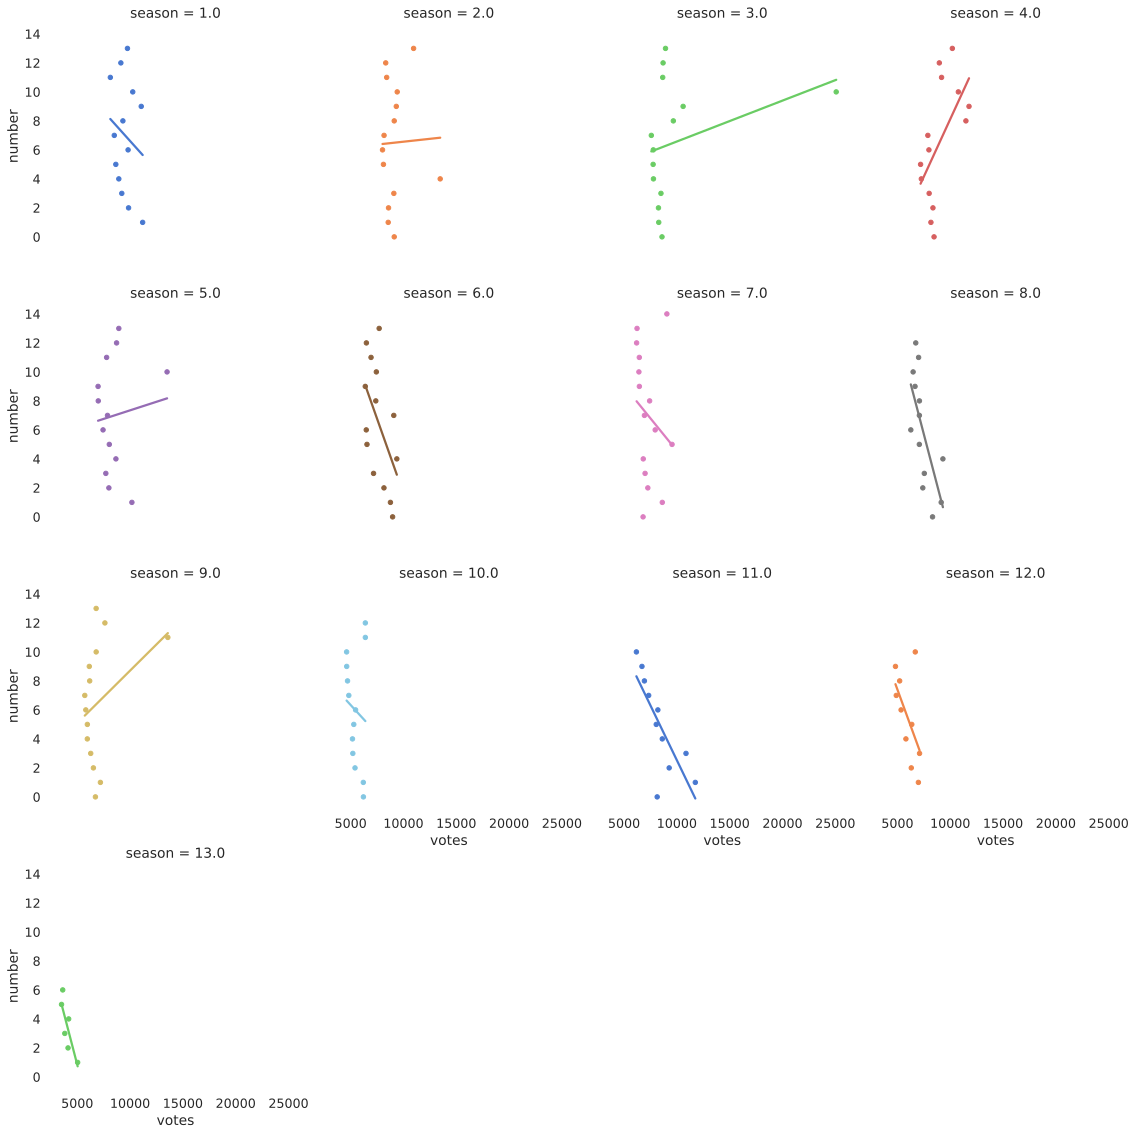

In [30]:
# Votes & Episode Number:
sns.lmplot(data=DF,  x='votes', y='number' , col='season' , hue='season', col_wrap=4, palette='muted',
             ci=None, height=4, scatter_kws={'s':20,'alpha':1})
sns.despine(top=True, left=True, bottom=True, right=True)
plt.show()

In [31]:
# PearSon – SpearMan – KenDall:
pd.Series({'pearson' :DF['votes'].corr(DF['number'], method='pearson' ),
           'spearman':DF['votes'].corr(DF['number'], method='spearman'),
           'kendall' :DF['votes'].corr(DF['number'], method='kendall' )}, name='correlation').to_frame()

,correlation
pearson,0.086590
spearman,0.015730
kendall,0.003949


In [32]:
# @title Temporal Patterns
# SeaSons:
DF.groupby('season')['rating'].agg(['mean','std'])

,mean,std
season,,
1.0,7.907692,0.855825
2.0,7.807143,1.049882
3.0,8.014286,0.963852
4.0,8.307143,0.783939
5.0,8.061538,0.893997
6.0,8.014286,0.793102
7.0,7.673333,0.651884
8.0,7.684615,0.818379
9.0,8.042857,0.862656


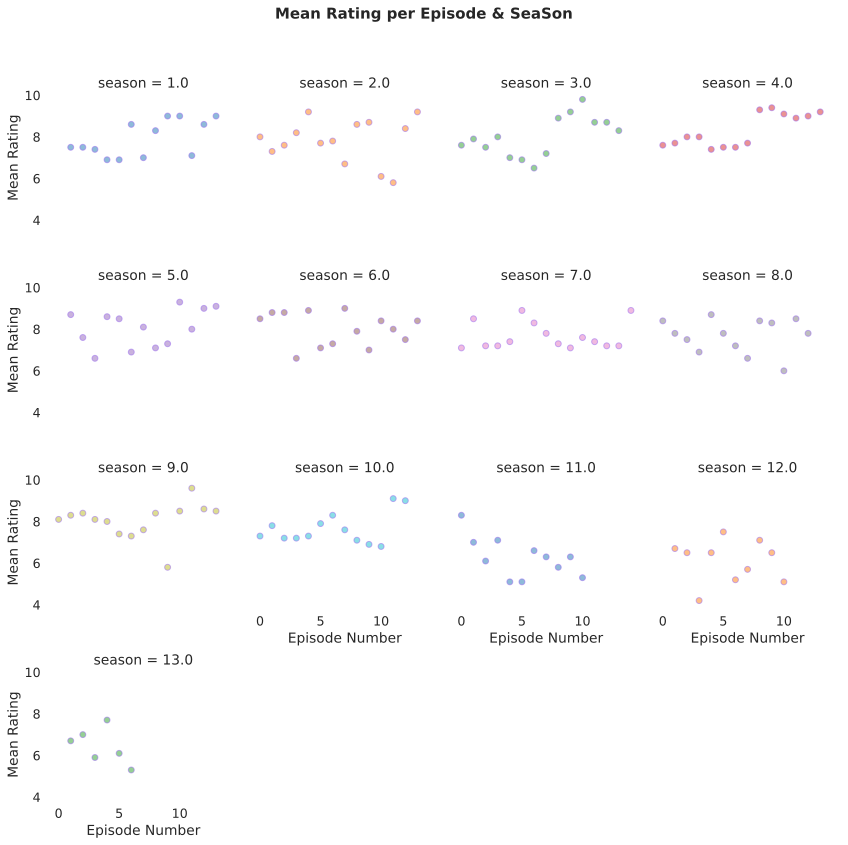

In [33]:
# SeaSon Ending vs. SeaSon Beginning:
g=sns.FacetGrid(DF, col='season', col_wrap=4, height=3, margin_titles=True)
g.map(plt.scatter, 'number','rating', color='#9565EE', alpha=.5)
g.set_axis_labels('Episode Number','Mean Rating')
g.fig.suptitle('Mean Rating per Episode & SeaSon', fontsize=15, fontweight='bold')
for ax, color in zip(g.axes.flat, sns.color_palette('tab10', n_colors=len(DF['season'].unique()))):
    ax.collections[0].set_facecolor(color)
plt.subplots_adjust(top=.88, hspace=.5)
sns.despine(top=True, left=True, bottom=True, right=True)
plt.show(   )

In [34]:
# @title Most Regular Season
# Less Ratings Variability:
results=DF.groupby('season')['rating'].agg(['mean','std'])
results.sort_values(by='std', ascending=True).head(13)

,mean,std
season,,
7.0,7.673333,0.651884
10.0,7.653846,0.745671
4.0,8.307143,0.783939
6.0,8.014286,0.793102
8.0,7.684615,0.818379
1.0,7.907692,0.855825
13.0,6.450000,0.857321
9.0,8.042857,0.862656
5.0,8.061538,0.893997


In [35]:
# Least Regular SeaSon:
results.sort_values(by='std', ascending=False).head(1)

,mean,std
season,,
2.0,7.807143,1.049882


In [36]:
# @title OutLiers
mean=DF['number'].mean()
std =DF['votes'     ].std ()
maxlim  =mean +  3  *  std
minlim  =mean -  3  *  std
outliers=DF[(DF['votes']>maxlim)|(DF['votes']<minlim)]
print('OutLiers:\n', outliers.to_string(index=False))

OutLiers:
      serie  season  number                     episode  year                  genre  runtime  votes  rating
Doctor Who     1.0     1.0                        Rose  2005 Adventure,Drama,Sci-Fi     45.0  11190     7.5
Doctor Who     1.0     2.0        The End of the World  2005 Adventure,Drama,Sci-Fi     45.0   9856     7.5
Doctor Who     1.0     3.0            The Unquiet Dead  2005 Adventure,Drama,Sci-Fi     45.0   9216     7.4
Doctor Who     1.0     4.0            Aliens of London  2005 Adventure,Drama,Sci-Fi     45.0   8933     6.9
Doctor Who     1.0     5.0             World War Three  2005 Adventure,Drama,Sci-Fi     45.0   8650     6.9
Doctor Who     1.0     6.0                       Dalek  2005 Adventure,Drama,Sci-Fi     45.0   9811     8.6
Doctor Who     1.0     7.0               The Long Game  2005 Adventure,Drama,Sci-Fi     45.0   8503     7.0
Doctor Who     1.0     8.0                Father's Day  2005 Adventure,Drama,Sci-Fi     45.0   9319     8.3
Doctor Who     1.

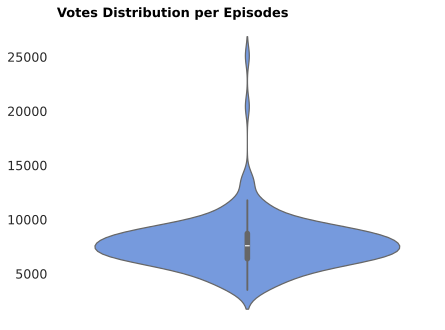

In [37]:
# Violin Plot:
plt.figure(tight_layout=True)
sns.violinplot(y=DF['votes'], color='#6595EE')
plt.title ('Votes Distribution per Episodes', fontdict=FontT, loc='left')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.show(    )

In [38]:
seasonMean=DF.groupby('season')['votes'].mean()
seasonSTD =DF.groupby('season')['votes'].std ()
OutLiersPerSeason={}
for season, mean, std in zip(seasonMean.index, seasonMean.values, seasonSTD.values):
    maxlim= mean + 3  *  std
    minlim= mean - 3  *  std
    seasonOutliers=DF[(DF['season']==season)&((DF['votes']>maxlim)|(DF['votes']<minlim))]
    if not seasonOutliers.empty: OutLiersPerSeason[season]=seasonOutliers
for season, outliers in OutLiersPerSeason.items():
    print(f'OutLiers from SeaSon {season}:\n', outliers.to_string(index=False),'\n')

OutLiers from SeaSon 3.0:
      serie  season  number episode  year                  genre  runtime  votes  rating
Doctor Who     3.0    10.0   Blink  2007 Adventure,Drama,Sci-Fi     45.0  25086     9.8 

OutLiers from SeaSon 9.0:
      serie  season  number     episode  year                  genre  runtime  votes  rating
Doctor Who     9.0    11.0 Heaven Sent  2015 Adventure,Drama,Sci-Fi     55.0  13575     9.6 



<ipython-input-39-8064fb94d0f4>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='votes', data=DF, ax=ax, palette=[palette[i]], legend=False)
<ipython-input-39-8064fb94d0f4>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='votes', data=DF, ax=ax, palette=[palette[i]], legend=False)


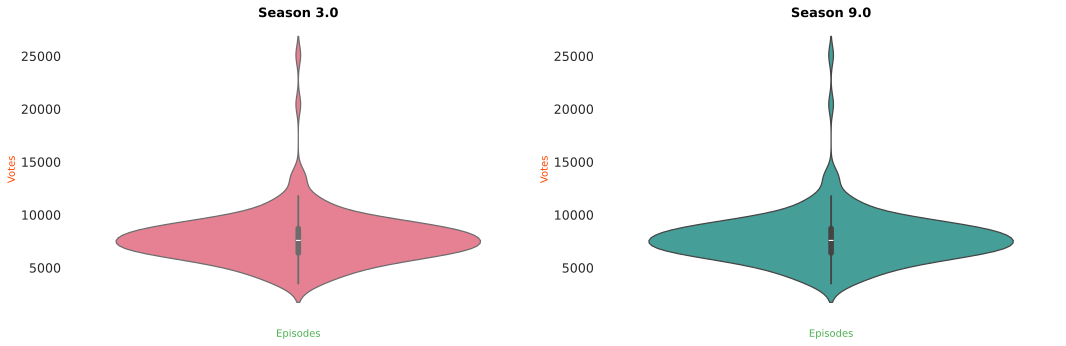

In [39]:
# Votes per SeaSon:
columns=2
rows   =-(-len(OutLiersPerSeason)//columns)
fig,axs=plt.subplots(rows, columns, figsize=(15, 5*rows))
palette=sns.color_palette('husl', n_colors=len(OutLiersPerSeason))
for i, (season, outliers) in enumerate(OutLiersPerSeason.items()):
    row    = i // columns
    column = i %  columns
    ax     = axs[row, column] if rows > 1 else axs[column]
    episodes=DF[(DF['season']==season)]
    sns.violinplot(y='votes', data=DF, ax=ax, palette=[palette[i]], legend=False)
    ax.set_title(f'Season {season}', fontdict=FontT)
    ax.set_ylabel('Votes'          , fontdict=FontY)
    ax.set_xlabel('Episodes'       , fontdict=FontX)
sns.despine(top=True, left=True, bottom=True, right=True)
plt.tight_layout(pad=1)
plt.show()

In [40]:
# Ratings per Episodes:
mean=DF['rating'].mean()
std =DF['rating'].std ()
maxlim  =mean +  2  *  std
minlim  =mean -  2  *  std
outliers=DF[(DF['rating']>maxlim)|(DF['votes']<minlim)]
print('OutLiers:\n', outliers.to_string(index=False))

OutLiers:
      serie  season  number episode  year                  genre  runtime  votes  rating
Doctor Who     3.0    10.0   Blink  2007 Adventure,Drama,Sci-Fi     45.0  25086     9.8


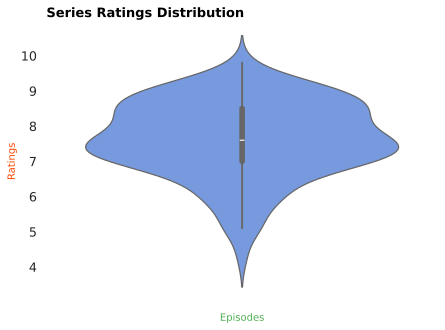

In [41]:
# VioLin Plot:
plt.figure(tight_layout=True)
sns.violinplot(y='rating', data=DF, color='#6595EE')
plt.title('Series Ratings Distribution', fontdict=FontT, loc='left')
plt.ylabel('Ratings'                   , fontdict=FontY)
plt.xlabel('Episodes'                  , fontdict=FontX)
plt.box(False)
plt.show(    )

In [42]:
# Mean Ratings per SeaSon:
seasonMean=DF.groupby('season')['rating'].mean()
seasonSTD =DF.groupby('season')['rating'].std ()
OutLiersPerSeason={}
for season, mean, std in zip(seasonMean.index, seasonMean.values, seasonSTD.values):
    maxlim= mean + 2  *  std
    minlim= mean - 2  *  std
    seasonOutliers=DF[(DF['season']==season)&((DF['rating']>maxlim)|(DF['rating']<minlim))]
    if not seasonOutliers.empty: OutLiersPerSeason[season]=seasonOutliers
for season, outliers in OutLiersPerSeason.items():
    print(f'OutLiers from SeaSon {season}:\n', outliers.to_string(index=False),'\n')

OutLiers from SeaSon 8.0:
      serie  season  number                    episode  year                  genre  runtime  votes  rating
Doctor Who     8.0    10.0 In the Forest of the Night  2014 Adventure,Drama,Sci-Fi     45.0   6484     6.0 

OutLiers from SeaSon 9.0:
      serie  season  number       episode  year                  genre  runtime  votes  rating
Doctor Who     9.0     9.0 Sleep No More  2015 Adventure,Drama,Sci-Fi     45.0   6138     5.8 

OutLiers from SeaSon 11.0:
      serie  season  number           episode  year                  genre  runtime  votes  rating
Doctor Who    11.0     0.0 Twice Upon a Time  2017 Adventure,Drama,Sci-Fi     60.0   8137     8.3 



<ipython-input-43-b7f085e5ae3b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='rating', data=DF, ax=ax, palette=[palette[i]], legend=False)
<ipython-input-43-b7f085e5ae3b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='rating', data=DF, ax=ax, palette=[palette[i]], legend=False)
<ipython-input-43-b7f085e5ae3b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='rating', data=DF, ax=ax, palette=[palette[i]], legend=False)


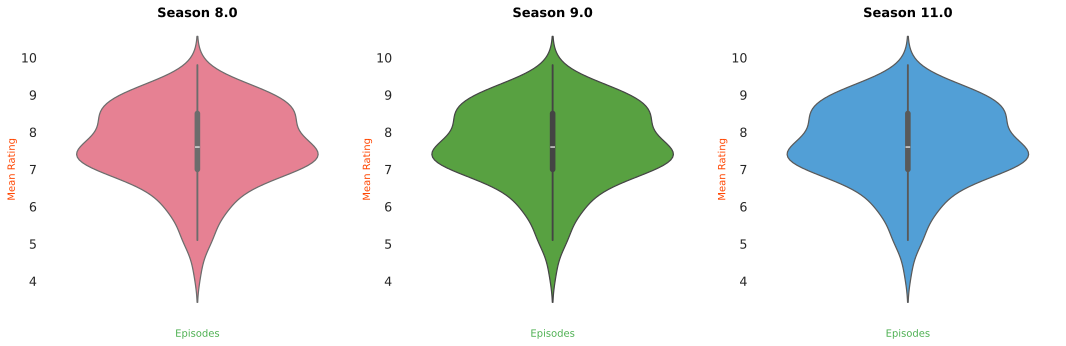

In [43]:
# Plots:
columns=3
rows   =-(-len(OutLiersPerSeason)//columns)
fig,axs=plt.subplots(rows, columns, figsize=(15, 5*rows))
palette=sns.color_palette('husl', n_colors=len(OutLiersPerSeason))
for i, (season, outliers) in enumerate(OutLiersPerSeason.items()):
    row    = i // columns
    column = i %  columns
    ax     = axs[row, column] if rows > 1 else axs[column]
    episodes=DF[(DF['season']==season)]
    sns.violinplot(y='rating', data=DF, ax=ax, palette=[palette[i]], legend=False)
    ax.set_title(f'Season {season}', fontdict=FontT)
    ax.set_ylabel('Mean Rating'    , fontdict=FontY)
    ax.set_xlabel('Episodes'       , fontdict=FontX)
sns.despine(top=True, left=True, bottom=True, right=True)
plt.tight_layout(pad=1)
plt.show()